In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey_results_public.csv")

C:\Users\Jared\AppData\Local\Temp\ipykernel_26120\1716283469.py:4: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("survey_results_public.csv")


In [2]:
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [3]:
df = df[["Country", "EdLevel", "YearsCode", "Employment", "ConvertedCompYearly"]]
df = df.rename({"ConvertedCompYearly": "Salary"}, axis=1)
df.head()


,Country,EdLevel,YearsCode,Employment,Salary
0,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Employed,61256.0
1,Netherlands,"Associate degree (A.A., A.S., etc.)",10.0,Employed,104413.0
2,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,"Independent contractor, freelancer, or self-em...",53061.0
3,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Employed,36197.0
4,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,"Independent contractor, freelancer, or self-em...",60000.0


In [4]:
df = df[df["Salary"].notnull()]
df.head()

,Country,EdLevel,YearsCode,Employment,Salary
0,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Employed,61256.0
1,Netherlands,"Associate degree (A.A., A.S., etc.)",10.0,Employed,104413.0
2,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,"Independent contractor, freelancer, or self-em...",53061.0
3,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Employed,36197.0
4,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,"Independent contractor, freelancer, or self-em...",60000.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 23947 entries, 0 to 49122
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Country     23947 non-null  str    
 1   EdLevel     23930 non-null  str    
 2   YearsCode   23838 non-null  float64
 3   Employment  23947 non-null  str    
 4   Salary      23947 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.9 MB


In [6]:
df = df.dropna()
df.isnull().sum()

Country       0
EdLevel       0
YearsCode     0
Employment    0
Salary        0
dtype: int64

In [7]:
df = df[df["Employment"] == "Employed"]
df = df.drop("Employment", axis=1)
df.info()

<class 'pandas.DataFrame'>
Index: 19414 entries, 0 to 49122
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    19414 non-null  str    
 1   EdLevel    19414 non-null  str    
 2   YearsCode  19414 non-null  float64
 3   Salary     19414 non-null  float64
dtypes: float64(2), str(2)
memory usage: 1.9 MB


In [8]:
df['Country'].value_counts()

Country
United States of America                                4517
Germany                                                 1812
United Kingdom of Great Britain and Northern Ireland    1269
India                                                    907
France                                                   820
                                                        ... 
Somalia                                                    1
Papua New Guinea                                           1
Djibouti                                                   1
Turkmenistan                                               1
Burundi                                                    1
Name: count, Length: 154, dtype: int64

In [9]:
def shorten_categories(categories, cutoff):
    categorical_map = {}
    for i in range(len(categories)):
        if categories.values[i] >= cutoff:
            categorical_map[categories.index[i]] = categories.index[i]
        else:
            categorical_map[categories.index[i]] = 'Other'
    return categorical_map

In [10]:
country_map = shorten_categories(df.Country.value_counts(), 400)
df['Country'] = df['Country'].map(country_map)
df.Country.value_counts()

Country
Other                                                   6382
United States of America                                4517
Germany                                                 1812
United Kingdom of Great Britain and Northern Ireland    1269
India                                                    907
France                                                   820
Canada                                                   754
Ukraine                                                  549
Netherlands                                              518
Brazil                                                   505
Italy                                                    468
Spain                                                    458
Australia                                                455
Name: count, dtype: int64

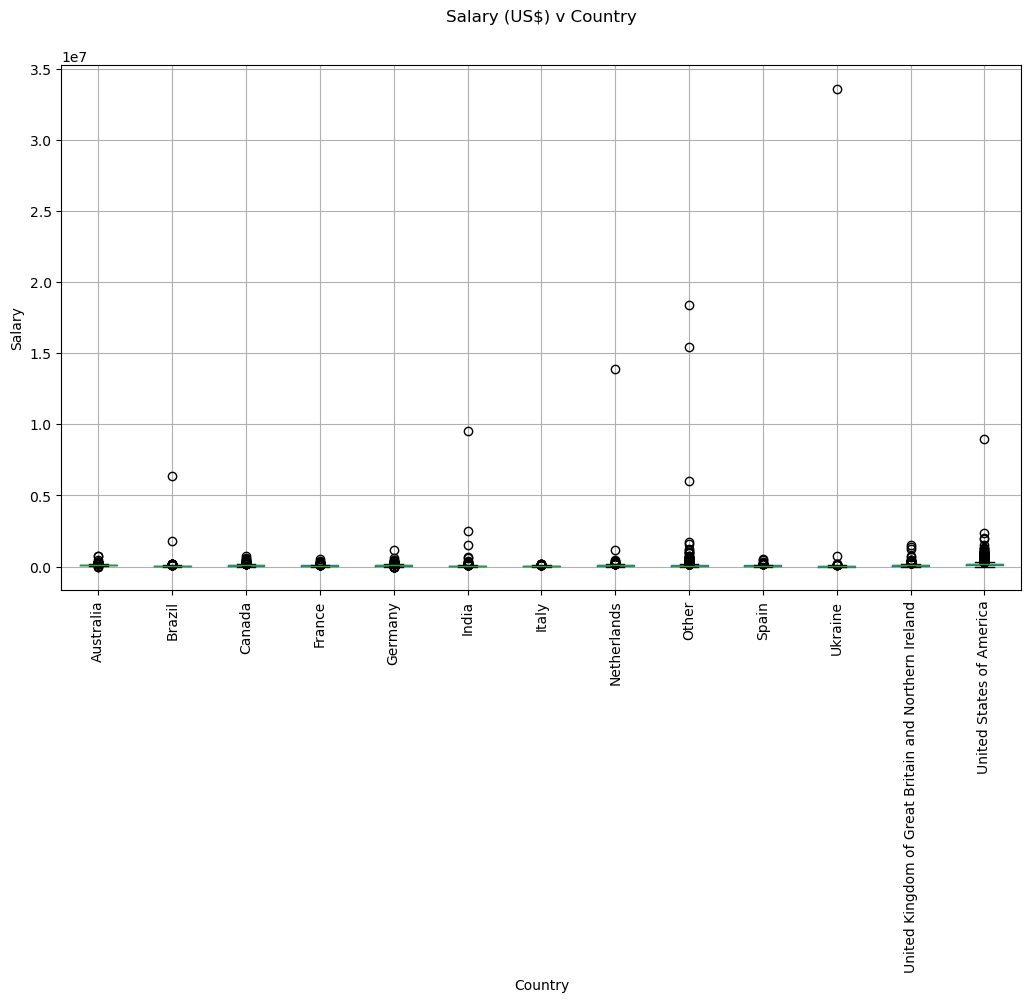

In [11]:
fig, ax = plt.subplots(1,1, figsize=(12, 7))
df.boxplot('Salary', 'Country', ax=ax)
plt.suptitle('Salary (US$) v Country')
plt.title('')
plt.ylabel('Salary')
plt.xticks(rotation=90)
plt.show()

In [12]:
df = df[df["Salary"] <= 250000]
df = df[df["Salary"] >= 10000]
df = df[df['Country'] != 'Other']

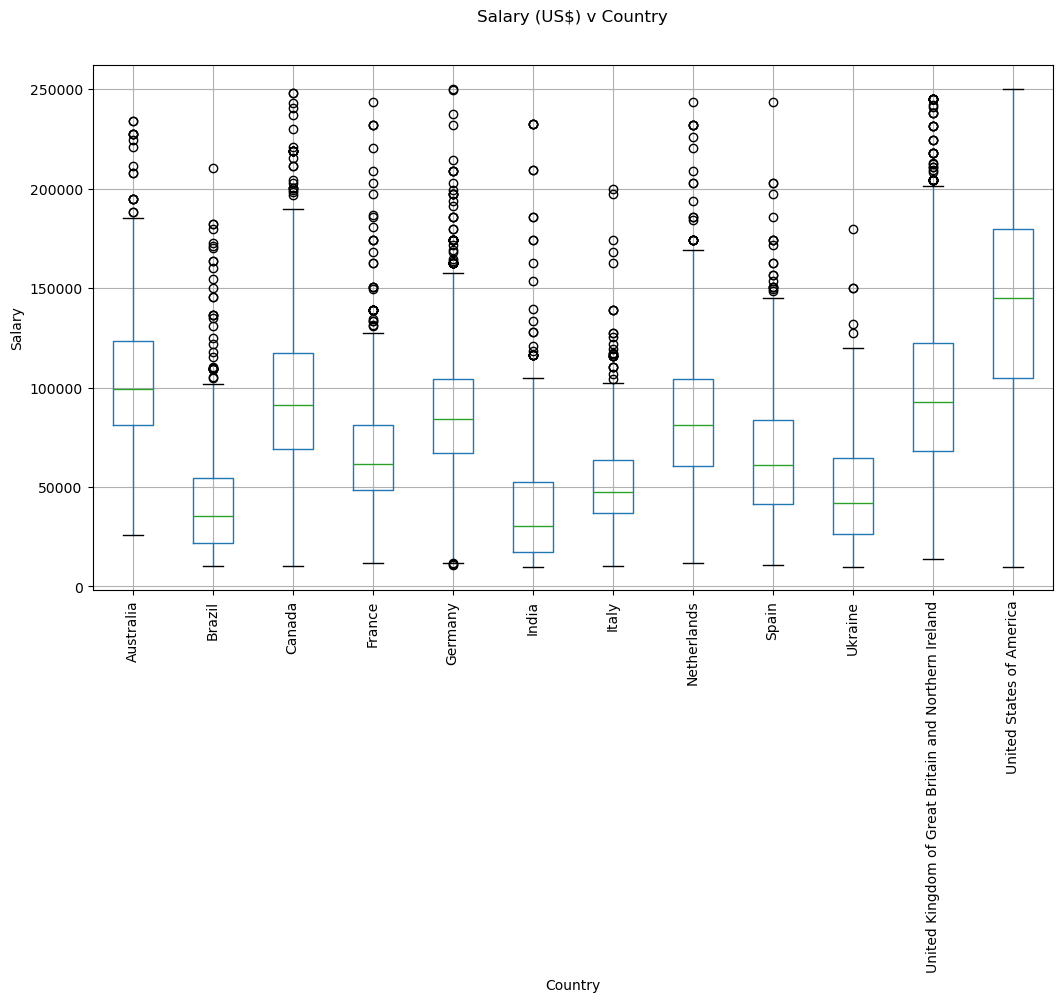

In [13]:
fig, ax = plt.subplots(1,1, figsize=(12, 7))
df.boxplot('Salary', 'Country', ax=ax)
plt.suptitle('Salary (US$) v Country')
plt.title('')
plt.ylabel('Salary')
plt.xticks(rotation=90)
plt.show()

In [15]:
df["YearsCode"].unique()

array([ 14.,  10.,   5.,  30.,  15.,   9.,  11.,  23.,  26.,  25.,   8.,
        38.,  35.,  21.,  19.,  18.,  13.,  20.,  41.,  16.,  45.,  17.,
        22.,  40.,  27.,   6.,   3.,  12.,  37.,   1.,  39.,  28.,  36.,
        33.,   7.,  24.,  29.,  50.,  44.,  31.,  46.,  52.,  42.,  43.,
         2.,  34.,  47.,  53.,  58.,   4.,  49.,  32.,  55.,  48.,  60.,
        59., 100.,  51.])

In [ ]:
# def clean_experience(x):
#     if x ==  'More than 50 years':
#         return 50
#     if x == 'Less than 1 year':
#         return 0.5
#     return float(x)

# df['YearsCodePro'] = df['YearsCodePro'].apply(clean_experience)

In [16]:
df["EdLevel"].unique()

<ArrowStringArray>
[                                   'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
                                                'Associate degree (A.A., A.S., etc.)',
                                       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
                                     'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
                             'Some college/university study without earning a degree',
 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
                                                          'Primary/elementary school',
                                                            'Other (please specify):']
Length: 8, dtype: str

In [17]:
def clean_education(x):
    if 'Bachelor’s degree' in x:
        return 'Bachelor’s degree'
    if 'Master’s degree' in x:
        return 'Master’s degree'
    if 'Professional degree' in x or 'Other doctoral' in x:
        return 'Post grad'
    return 'Less than a Bachelors'

df['EdLevel'] = df['EdLevel'].apply(clean_education)

In [18]:
df["EdLevel"].unique()

<ArrowStringArray>
['Master’s degree', 'Less than a Bachelors', 'Bachelor’s degree', 'Post grad']
Length: 4, dtype: str

In [19]:
from sklearn.preprocessing import LabelEncoder
le_education = LabelEncoder()
df['EdLevel'] = le_education.fit_transform(df['EdLevel'])
df["EdLevel"].unique()
#le.classes_

array([2, 1, 0, 3])

In [20]:
le_country = LabelEncoder()
df['Country'] = le_country.fit_transform(df['Country'])
df["Country"].unique()

array([ 9,  7, 11,  4, 10,  8,  2,  1,  6,  5,  3,  0])

In [21]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [22]:
from sklearn.linear_model import LinearRegression
linear_reg = LinearRegression()
linear_reg.fit(X, y.values)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_pred = linear_reg.predict(X)

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
error = np.sqrt(mean_squared_error(y, y_pred))


In [25]:
error

np.float64(46666.52463819027)

In [26]:
from sklearn.tree import DecisionTreeRegressor
dec_tree_reg = DecisionTreeRegressor(random_state=0)
dec_tree_reg.fit(X, y.values)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [27]:
DecisionTreeRegressor(random_state=0)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [28]:
y_pred = dec_tree_reg.predict(X)

In [29]:
error = np.sqrt(mean_squared_error(y, y_pred))
print("${:,.02f}".format(error))

$36,125.09


In [30]:
from sklearn.ensemble import RandomForestRegressor
random_forest_reg = RandomForestRegressor(random_state=0)
random_forest_reg.fit(X, y.values)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
y_pred = random_forest_reg.predict(X)

In [32]:
error = np.sqrt(mean_squared_error(y, y_pred))
print("${:,.02f}".format(error))

$36,273.42


In [33]:
from sklearn.model_selection import GridSearchCV

max_depth = [None, 2,4,6,8,10,12]
parameters = {"max_depth": max_depth}

regressor = DecisionTreeRegressor(random_state=0)
gs = GridSearchCV(regressor, parameters, scoring='neg_mean_squared_error')
gs.fit(X, y.values)

,estimator,DecisionTreeR...andom_state=0)
,param_grid,"{'max_depth': [None, 2, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [34]:
regressor = gs.best_estimator_

regressor.fit(X, y.values)
y_pred = regressor.predict(X)
error = np.sqrt(mean_squared_error(y, y_pred))
print("${:,.02f}".format(error))

$38,187.26


In [35]:
X

,Country,EdLevel,YearsCode
0,9,2,14.0
1,7,1,10.0
3,9,0,5.0
7,9,3,30.0
8,9,0,15.0
...,...,...,...
49066,0,0,22.0
49075,10,2,10.0
49083,11,0,5.0
49121,3,1,14.0


In [39]:
# country, edlevel, yearscode
X = np.array([["United States of America", 'Master’s degree', 15 ]])
X

array([['United States of America', 'Master’s degree', '15']],
      dtype='<U24')

In [40]:
X[:, 0] = le_country.transform(X[:,0])
X[:, 1] = le_education.transform(X[:,1])
X = X.astype(float)
X

array([[11.,  2., 15.]])

In [41]:
y_pred = regressor.predict(X)
y_pred

C:\Users\Jared\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([156196.80851064])

In [42]:
import pickle

In [43]:
data = {"model": regressor, "le_country": le_country, "le_education": le_education}
with open('saved_steps.pkl', 'wb') as file:
    pickle.dump(data, file)

In [44]:
with open('saved_steps.pkl', 'rb') as file:
    data = pickle.load(file)

regressor_loaded = data["model"]
le_country = data["le_country"]
le_education = data["le_education"]

In [45]:
y_pred = regressor.predict(X)
y_pred

C:\Users\Jared\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([156196.80851064])